---
title: NDVI Time-Series Analysis: Sentinel-2 vs Sentinel-3
subtitle: Multi-scale NDVI analysis combining Sentinel-2 and Sentinel-3 EOPF Zarr products to monitor storm impacts
authors:
  - name: Yuvraj Bhagwan Adagale
    orcid: 0009-0008-1259-3399
    github: Yuvraj198920
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-10-07
thumbnail: ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
keywords: ["xarray", "earth observation", "remote sensing", "ndvi", "time-series"]
tags: ["sentinel-2", "sentinel-3", "ndvi", "land"]
releaseDate: 2025-10-07
datePublished: 2025-10-07
dateModified: 2025-12-12
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents

1. [Introduction](#introduction)
2. [Import Modules](#import-modules)
3. [Define Study Area & Time Period](#study-area)
4. [Data Discovery via STAC](#data-discovery)
5. [Sentinel-2 NDVI Processing](#s2-processing)
6. [Sentinel-3 NDVI Processing](#s3-processing)
7. [Merge and Analyze Time Series](#merge-analysis)
8. [Multi-Scale Comparison](#multi-scale-comparison)
9. [Storm Impact Detection](#storm-impact)
10. [Combination Strategies](#combination-strategies)
11. [Conclusions](#conclusions)

(introduction)=
## Introduction

This notebook demonstrates how to analyze NDVI (Normalized Difference Vegetation Index) time-series by combining data from both Sentinel-2 and Sentinel-3 satellites stored in EOPF Zarr format. Using the Vaia storm (October 2018) as a case study, we explore how multi-scale satellite observations can provide complementary insights into vegetation dynamics and storm damage assessment.

### Why Use Both Sentinel-2 and Sentinel-3?

Storm impacts like the Vaia windstorm operate at multiple spatial scales - from individual trees to entire landscapes. Using both Sentinel-2 (10m resolution) and Sentinel-3 (300m resolution) provides:

1. **Multi-Scale Perspective**: S2 captures fine-scale damage patterns while S3 shows landscape-level trends
2. **Cross-Validation**: Independent measurements from different sensors strengthen scientific confidence
3. **Complementary Temporal Coverage**: S3's daily revisit catches rapid changes; S2's 5-day cycle provides detailed mapping

### NDVI Calculation Bands

**Sentinel-2**: Uses B04 (665nm, red) and B08 (842nm, NIR)

**Sentinel-3**: Uses Oa08_reflectance (665nm, red) and Oa17_reflectance (865nm, NIR)

Both band combinations are optimized for vegetation monitoring, located at chlorophyll absorption maxima (red) and the NIR plateau where healthy vegetation has high reflectance.

:::{hint} Overview
**Questions**
- How can I combine NDVI data from Sentinel-2 and Sentinel-3 for multi-scale vegetation analysis?
- How do I use STAC to discover and access EOPF Zarr products?
- How can different spatial resolutions be compared for the same region?
- What are effective strategies for combining multi-sensor observations?

**Objectives**
- Access Sentinel-2 and Sentinel-3 EOPF Zarr products via STAC catalog
- Calculate NDVI time-series from both sensors for the same study area
- Compare and validate NDVI values across different spatial scales
- Detect the Vaia storm impact using multi-sensor analysis
- Explore combination strategies for multi-scale satellite data
:::

<a id="setup"></a>
## <a id='toc1_3_'></a>[Import Libraries and Setup](#toc0_)

In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import os
import warnings
import geojson
import pystac_client
from shapely.geometry import box

try:
    import folium

    print("Folium already installed")
except ImportError:
    print("Installing folium for interactive mapping...")
    import subprocess

    subprocess.check_call(["pip", "install", "folium"])
    import folium

    print("Folium installed successfully")

print("Libraries imported successfully!")

Folium already installed
Libraries imported successfully!


## <a id='toc1_4_'></a>[Define Study Area & Time Period](#toc0_)

In [2]:
# Define Area of Interest (Bolzano/South Tyrol region)
spatial_extent = {
    "west": 11.46309533,
    "south": 46.28795898,
    "east": 11.75355181,
    "north": 46.40587491,
}

# Define temporal extent (3+ years around Vaia storm)
temporal_extent = ["2017-09-01", "2020-09-30"]

# Create a polygon from your spatial extent
bbox_geom = box(
    spatial_extent["west"],
    spatial_extent["south"],
    spatial_extent["east"],
    spatial_extent["north"],
)
bbox_geojson = geojson.Feature(geometry=bbox_geom, properties={})
print(f"Spatial extent: {spatial_extent}")
print(f"Temporal extent: {temporal_extent}")

Spatial extent: {'west': 11.46309533, 'south': 46.28795898, 'east': 11.75355181, 'north': 46.40587491}
Temporal extent: ['2017-09-01', '2020-09-30']


<a id="data-processing"></a>
## <a id='toc1_5_'></a>[Discover Products using STAC](#toc0_)

Discover Sentinel-2 and Sentinel-3 products using the EOPF STAC catalog at `https://stac.core.eopf.eodc.eu`.

In [3]:
# Discover products using STAC catalog
STAC_URL = "https://stac.core.eopf.eodc.eu"
catalog = pystac_client.Client.open(STAC_URL)

# Define bounding box from study area
bbox = [
    spatial_extent["west"],
    spatial_extent["south"],
    spatial_extent["east"],
    spatial_extent["north"],
]

# Discover Sentinel-2 L2A products
print("Discovering Sentinel-2 products from STAC catalog...")
s2_items = list(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=temporal_extent,
    ).items()
)
print(f"✅ Found {len(s2_items)} Sentinel-2 L2A products")

# Discover Sentinel-3 OLCI L1 EFR products
print("\nDiscovering Sentinel-3 products from STAC catalog...")
s3_items = list(
    catalog.search(
        collections=["sentinel-3-olci-l1-efr"],
        bbox=bbox,
        datetime=temporal_extent,
    ).items()
)
print(f"✅ Found {len(s3_items)} Sentinel-3 OLCI L1 EFR products")

print(f"\nTotal: {len(s2_items)} S2 + {len(s3_items)} S3 products")

# Display sample items
if s2_items:
    print(f"\nSample Sentinel-2 product: {s2_items[0].id}")
if s3_items:
    print(f"Sample Sentinel-3 product: {s3_items[0].id}")

Discovering Sentinel-2 products from STAC catalog...
✅ Found 448 Sentinel-2 L2A products

Discovering Sentinel-3 products from STAC catalog...
✅ Found 1399 Sentinel-3 OLCI L1 EFR products

Total: 448 S2 + 1399 S3 products

Sample Sentinel-2 product: S2B_MSIL2A_20200930T100729_N0500_R022_T32TPS_20230420T090422
Sample Sentinel-3 product: S3B_OL_1_EFR____20200930T095220_20200930T095520_20240526T114207_0179_044_079_2160_MAR_R_NT_004


## <a id='toc1_6_'></a>[Sentinel-2 NDVI Processing](#toc0_)

Process Sentinel-2 products using ThreadPoolExecutor for efficient I/O-bound parallel processing.

In [4]:
import pickle
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- Configuration ---
NUM_WORKERS = 4
ENABLE_CACHE = True
# Use absolute path for cache directory
CACHE_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "cache")
os.makedirs(CACHE_DIR, exist_ok=True)

S2_CACHE_FILE = os.path.join(CACHE_DIR, "s2_ndvi_cache.pkl")
S3_CACHE_FILE = os.path.join(CACHE_DIR, "s3_ndvi_cache.pkl")


# --- Helper Functions ---
def load_cache(cache_file):
    if ENABLE_CACHE and cache_file and os.path.exists(cache_file):
        try:
            with open(cache_file, "rb") as f:
                return pickle.load(f)
        except Exception as e:
            print(f"⚠️ Cache load failed: {e}")
    return {}


def save_cache(cache_file, results_dict):
    if ENABLE_CACHE and cache_file:
        try:
            with open(cache_file, "wb") as f:
                pickle.dump(results_dict, f)
        except Exception:
            pass


# --- Sentinel-2 Processing ---
def process_s2_item(item, bbox_geometry):
    """Process S2 STAC item with early clipping for performance."""
    try:
        product_url = item.assets["product"].href
        open_kwargs = item.assets["product"].extra_fields.get(
            "xarray:open_datatree_kwargs", {}
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            # Open using STAC metadata
            dt = xr.open_datatree(product_url, **open_kwargs)

            groups_normalized = [g.lstrip("/") for g in dt.groups]
            path_10m = "measurements/reflectance/r10m"

            try:
                ds_10m = dt[path_10m].to_dataset()
            except KeyError:
                return None

            # Set CRS if missing
            if ds_10m.rio.crs is None:
                if "spatial_ref" in ds_10m.coords:
                    spatial_ref = ds_10m.coords["spatial_ref"]
                    crs = spatial_ref.attrs.get("spatial_ref") or spatial_ref.attrs.get(
                        "crs_wkt", "EPSG:32632"
                    )
                else:
                    crs = "EPSG:32632"
                ds_10m.rio.write_crs(crs, inplace=True)

            # Clip early
            try:
                ds_clipped = ds_10m.rio.clip(
                    [bbox_geometry], crs="EPSG:4326", all_touched=True
                )
            except Exception:
                return None

            b04 = ds_clipped["b04"].values
            b08 = ds_clipped["b08"].values

            # NDVI calculation
            with np.errstate(divide="ignore", invalid="ignore"):
                ndvi = (b08 - b04) / (b08 + b04)

            # SCL masking (optional)
            path_20m = "conditions/mask/l2a_classification/r20m"
            if path_20m in groups_normalized:
                try:
                    ds_20m = dt[path_20m].to_dataset()
                    if ds_20m.rio.crs is None:
                        ds_20m.rio.write_crs(ds_10m.rio.crs, inplace=True)
                    ds_20m_clipped = ds_20m.rio.clip(
                        [bbox_geometry], crs="EPSG:4326", all_touched=True
                    )

                    scl_var = (
                        "scl"
                        if "scl" in ds_20m_clipped
                        else "SCL" if "SCL" in ds_20m_clipped else None
                    )
                    if scl_var:
                        scl = ds_20m_clipped[scl_var].values
                        # Simple nearest-neighbor upsampling
                        from scipy.ndimage import zoom

                        scale_y = b04.shape[0] / scl.shape[0]
                        scale_x = b04.shape[1] / scl.shape[1]
                        scl_upsampled = zoom(scl, (scale_y, scale_x), order=0)
                        # Mask: keep vegetation (4,5), bare soil (6), water (7)
                        mask = np.isin(scl_upsampled, [4, 5, 6, 7])
                        ndvi = np.where(mask, ndvi, np.nan)
                except Exception:
                    pass  # Skip masking if it fails

            mean_ndvi = float(np.nanmean(ndvi))

            if np.isnan(mean_ndvi) or mean_ndvi < -1 or mean_ndvi > 1:
                return None

            # Parse date from item datetime
            product_time = datetime.fromisoformat(
                item.datetime.isoformat()
                if item.datetime
                else item.properties["datetime"]
            )

            return {"time": product_time, "ndvi": mean_ndvi, "product": item.id}

    except Exception:
        return None


# --- Main Execution ---
s2_cache = load_cache(S2_CACHE_FILE)
s2_to_process = [item for item in s2_items if item.id not in s2_cache]

print(f"📊 S2: {len(s2_cache)} cached, {len(s2_to_process)} to process")

if s2_to_process:
    print(
        f"\n🛰️ Processing {len(s2_to_process)} S2 products with {NUM_WORKERS} threads..."
    )

    bbox_geom = bbox_geojson["geometry"]

    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        futures = {
            executor.submit(process_s2_item, item, bbox_geom): item
            for item in s2_to_process
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="S2"):
            result = future.result()
            if result:
                s2_cache[result["product"]] = result
                # Save periodically
                if len(s2_cache) % 50 == 0:
                    save_cache(S2_CACHE_FILE, s2_cache)

    save_cache(S2_CACHE_FILE, s2_cache)

# Create DataFrame
s2_results = [v for v in s2_cache.values() if v is not None]
s2_ndvi_df = pd.DataFrame(s2_results)

if not s2_ndvi_df.empty:
    s2_ndvi_df = s2_ndvi_df.sort_values("time").reset_index(drop=True)
    if "product" in s2_ndvi_df.columns:
        s2_ndvi_df = s2_ndvi_df.drop(columns=["product"])
    print(f"✅ Sentinel-2 Complete: {len(s2_ndvi_df)} valid records")
    print(s2_ndvi_df.head())
else:
    print("⚠️ No valid Sentinel-2 data found.")

/home/yadagale/work/notebooks281125/eopf-sample-notebooks/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📊 S2: 0 cached, 448 to process

🛰️ Processing 448 S2 products with 4 threads...


S2: 100%|██████████| 448/448 [31:21<00:00,  4.20s/it]

✅ Sentinel-2 Complete: 319 valid records
                              time      ndvi
0 2017-09-04 10:20:21.026000+00:00  0.632733
1 2017-09-06 10:10:19.027000+00:00  0.529864
2 2017-09-09 10:20:19.027000+00:00  0.301714
3 2017-09-14 10:20:21.026000+00:00  0.636473
4 2017-09-16 10:10:19.027000+00:00  0.546925


## <a id='toc1_7_'></a>[Sentinel-3 NDVI Processing](#toc0_)

Process Sentinel-3 OLCI Level-1 products. The EODC dataset contains radiance data (OL_1_EFR), so we convert radiance to TOA reflectance using:

$$\rho = \frac{\pi \cdot L}{F_0 \cdot \cos(\theta_s)}$$

Where:
- $L$ = TOA Radiance (from `oa08_radiance` and `oa17_radiance`)
- $F_0$ = Solar Irradiance (from `solar_flux`)
- $\theta_s$ = Solar Zenith Angle (from `sza`)

In [5]:
# --- Sentinel-3 Processing ---
def process_s3_item(item):
    """Process S3 STAC item with radiance-to-reflectance conversion."""
    try:
        product_url = item.assets["product"].href
        open_kwargs = item.assets["product"].extra_fields.get(
            "xarray:open_datatree_kwargs", {}
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            dt = xr.open_datatree(product_url, **open_kwargs)

            ds = dt["measurements"].to_dataset()
            oa08_rad = ds["oa08_radiance"].values
            oa17_rad = ds["oa17_radiance"].values

            # Get SZA and interpolate to full resolution
            geo_ds = dt["conditions/geometry"].to_dataset()
            sza = geo_ds["sza"].values

            # Interpolate SZA from tie-point grid (77 cols) to full resolution (4865 cols)
            from scipy.ndimage import zoom

            scale_y = oa08_rad.shape[0] / sza.shape[0]
            scale_x = oa08_rad.shape[1] / sza.shape[1]
            sza_interp = zoom(sza, (scale_y, scale_x), order=1)

            cos_sza = np.cos(np.deg2rad(sza_interp))
            cos_sza = np.clip(cos_sza, 0.1, 1.0)  # Avoid division issues

            # Get solar flux constants
            inst_ds = dt["conditions/instrument"].to_dataset()
            solar_flux = inst_ds["solar_flux"].values
            f0_oa08 = float(np.mean(solar_flux[7]))
            f0_oa17 = float(np.mean(solar_flux[16]))

            # Convert radiance to reflectance: ρ = π * L / (F₀ * cos(SZA))
            oa08_refl = (np.pi * oa08_rad) / (f0_oa08 * cos_sza)
            oa17_refl = (np.pi * oa17_rad) / (f0_oa17 * cos_sza)

            # Calculate NDVI
            with np.errstate(divide="ignore", invalid="ignore"):
                ndvi = (oa17_refl - oa08_refl) / (oa17_refl + oa08_refl)

            mean_ndvi = float(np.nanmean(ndvi))

            if np.isnan(mean_ndvi) or mean_ndvi < -1 or mean_ndvi > 1:
                return None

            # Parse date from item datetime
            product_time = datetime.fromisoformat(
                item.datetime.isoformat()
                if item.datetime
                else item.properties["datetime"]
            )

            return {"time": product_time, "ndvi": mean_ndvi, "product": item.id}

    except Exception:
        return None


# --- Execute S3 ---
s3_cache = load_cache(S3_CACHE_FILE)
s3_to_process = [item for item in s3_items if item.id not in s3_cache]

print(f"📊 S3: {len(s3_cache)} cached, {len(s3_to_process)} to process")

if s3_to_process:
    print(
        f"\n🛰️ Processing {len(s3_to_process)} S3 products with {NUM_WORKERS} threads..."
    )

    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        futures = {
            executor.submit(process_s3_item, item): item for item in s3_to_process
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="S3"):
            result = future.result()
            if result:
                s3_cache[result["product"]] = result
                if len(s3_cache) % 50 == 0:
                    save_cache(S3_CACHE_FILE, s3_cache)

    save_cache(S3_CACHE_FILE, s3_cache)

# Create DataFrame
s3_results = [v for v in s3_cache.values() if v is not None]
s3_ndvi_df = pd.DataFrame(s3_results)

if not s3_ndvi_df.empty:
    s3_ndvi_df = s3_ndvi_df.sort_values("time").reset_index(drop=True)
    if "product" in s3_ndvi_df.columns:
        s3_ndvi_df = s3_ndvi_df.drop(columns=["product"])
    print(f"✅ Sentinel-3 Complete: {len(s3_ndvi_df)} valid records")
    print(s3_ndvi_df.head())
else:
    print("⚠️ No valid Sentinel-3 data found.")

📊 S3: 0 cached, 1399 to process

🛰️ Processing 1399 S3 products with 4 threads...


S3:   0%|          | 0/1399 [00:00<?, ?it/s]

S3: 100%|██████████| 1399/1399 [29:24<00:00,  1.26s/it]

✅ Sentinel-3 Complete: 1399 valid records
                              time      ndvi
0 2017-09-01 09:59:24.280776+00:00  0.161377
1 2017-09-02 09:33:13.140846+00:00  0.115294
2 2017-09-03 09:07:02.024828+00:00  0.117077
3 2017-09-05 09:55:38.944098+00:00  0.192407
4 2017-09-06 09:29:27.783051+00:00  0.155280



💾 Generating Final DataFrames...
✅ Sentinel-2: 319 records
✅ Sentinel-3: 1399 records

🔗 Combined Data (First 10 rows):
                              time   satellite      ndvi  \
0 2017-09-01 09:59:24.280776+00:00  Sentinel-3  0.161377   
1 2017-09-02 09:33:13.140846+00:00  Sentinel-3  0.115294   
2 2017-09-03 09:07:02.024828+00:00  Sentinel-3  0.117077   
3 2017-09-04 10:20:21.026000+00:00  Sentinel-2  0.632733   
4 2017-09-05 09:55:38.944098+00:00  Sentinel-3  0.192407   
5 2017-09-06 09:29:27.783051+00:00  Sentinel-3  0.155280   
6 2017-09-06 10:10:19.027000+00:00  Sentinel-2  0.529864   
7 2017-09-07 09:03:17.062236+00:00  Sentinel-3  0.212805   
8 2017-09-09 09:51:54.833343+00:00  Sentinel-3  0.105215   
9 2017-09-09 10:20:19.027000+00:00  Sentinel-2  0.301714   

                                             product  
0  S3A_OL_1_EFR____20170901T095754_20170901T10005...  
1  S3A_OL_1_EFR____20170902T093143_20170902T09344...  
2  S3A_OL_1_EFR____20170903T090532_20170903T09083... 

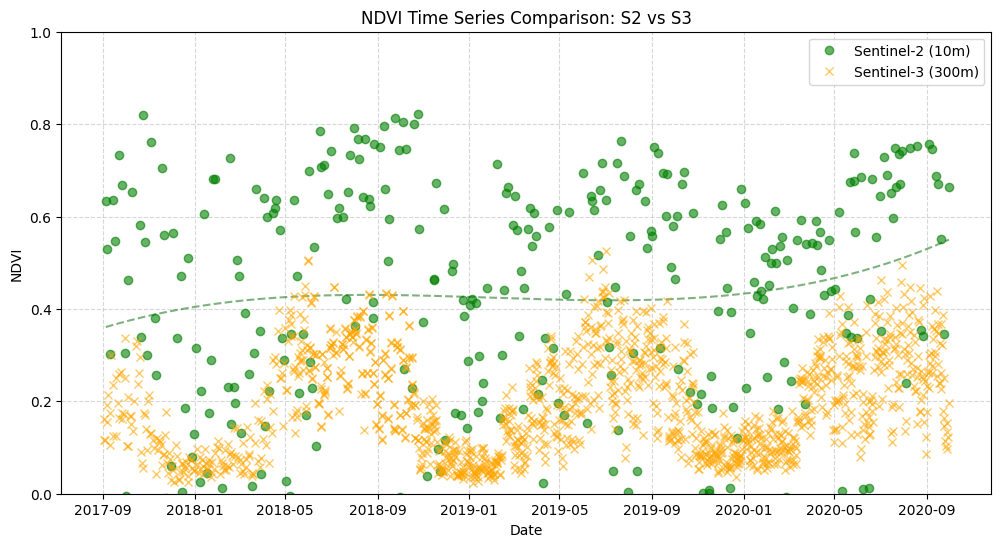

In [6]:
# --- DataFrame Construction & Merging ---

print("\n💾 Generating Final DataFrames...")

# 1. Process Sentinel-2 Results
s2_results = [v for v in s2_cache.values() if v is not None]
df_s2 = pd.DataFrame(s2_results)

if not df_s2.empty:
    df_s2["satellite"] = "Sentinel-2"
    df_s2 = df_s2.sort_values("time").reset_index(drop=True)
    print(f"✅ Sentinel-2: {len(df_s2)} records")

# 2. Process Sentinel-3 Results
s3_results = [v for v in s3_cache.values() if v is not None]
df_s3 = pd.DataFrame(s3_results)

if not df_s3.empty:
    df_s3["satellite"] = "Sentinel-3"
    df_s3 = df_s3.sort_values("time").reset_index(drop=True)
    print(f"✅ Sentinel-3: {len(df_s3)} records")

# 3. Create Combined DataFrame
dfs_to_merge = []
if not df_s2.empty:
    dfs_to_merge.append(df_s2)
if not df_s3.empty:
    dfs_to_merge.append(df_s3)

if dfs_to_merge:
    final_df = pd.concat(dfs_to_merge)

    # Sort by time
    final_df = final_df.sort_values("time").reset_index(drop=True)

    # Reorder columns for readability
    cols = ["time", "satellite", "ndvi", "product"]
    final_df = final_df[cols]

    print("\n🔗 Combined Data (First 10 rows):")
    print(final_df.head(10))

    # Optional: Save to CSV
    final_df.to_csv("ndvi_timeseries_combined.csv", index=False)
    print("\n📁 Saved to 'ndvi_timeseries_combined.csv'")
else:
    print("\n⚠️ No valid data found for either satellite.")

# --- Visualization Snippet (Optional) ---
# If you are in a Jupyter Notebook, this plots the comparison instantly
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))

    if not df_s2.empty:
        plt.plot(
            df_s2["time"],
            df_s2["ndvi"],
            "o",
            alpha=0.6,
            label="Sentinel-2 (10m)",
            color="green",
        )
        # Add trendline for S2
        if len(df_s2) > 2:
            z = np.polyfit(pd.to_numeric(df_s2["time"]), df_s2["ndvi"], 3)
            p = np.poly1d(z)
            plt.plot(
                df_s2["time"],
                p(pd.to_numeric(df_s2["time"])),
                "--",
                color="darkgreen",
                alpha=0.5,
            )

    if not df_s3.empty:
        plt.plot(
            df_s3["time"],
            df_s3["ndvi"],
            "x",
            alpha=0.6,
            label="Sentinel-3 (300m)",
            color="orange",
        )

    plt.title("NDVI Time Series Comparison: S2 vs S3")
    plt.ylabel("NDVI")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.ylim(0, 1)  # NDVI is typically 0-1 for vegetation
    plt.show()


except ImportError:
    print("Matplotlib not installed, skipping plot.")

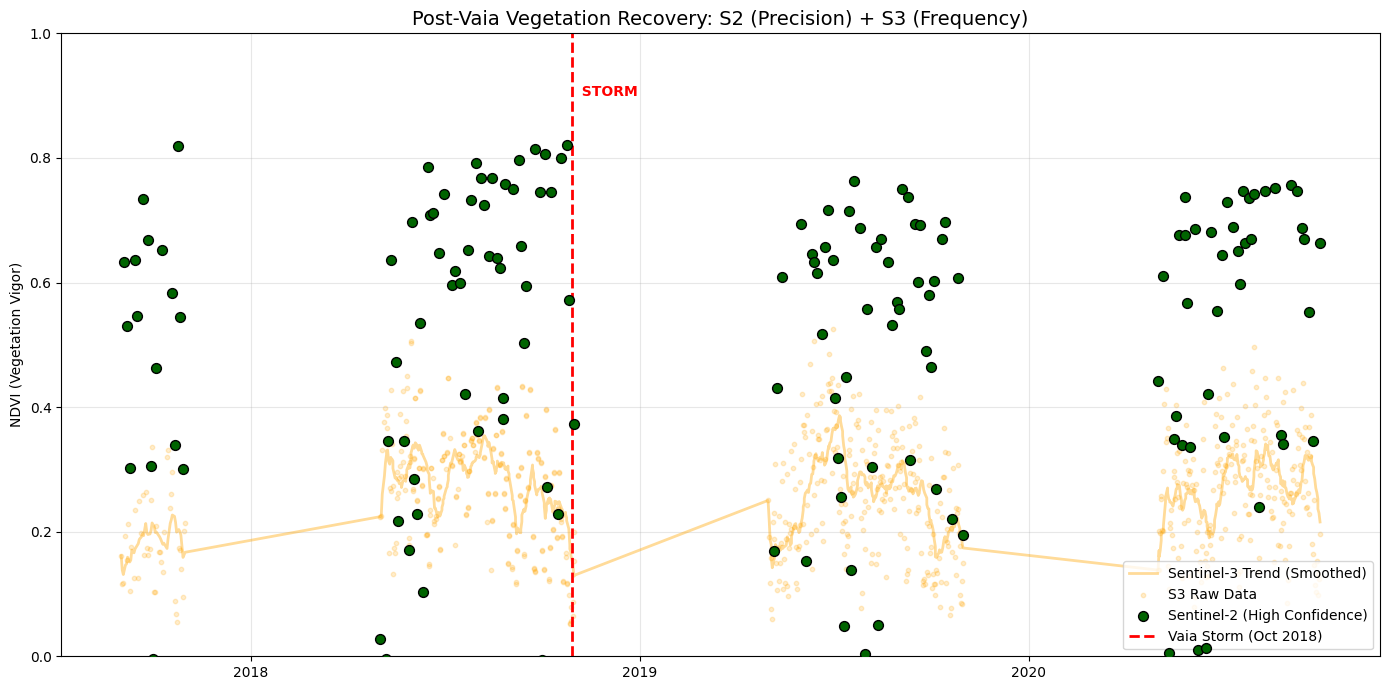

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure 'time' is datetime
final_df["time"] = pd.to_datetime(final_df["time"])

# --- 1. Filter Logic for Vaia Analysis ---
# Remove winter months (Nov-March) where snow confuses NDVI in the Alps
# (Optional: keep if you trust your snow masking)
final_df["month"] = final_df["time"].dt.month
summer_df = final_df[final_df["month"].between(5, 10)].copy()

# Separate Satellites
s2_data = summer_df[summer_df["satellite"] == "Sentinel-2"]
s3_data = summer_df[summer_df["satellite"] == "Sentinel-3"]

# --- 2. Smoothing Sentinel-3 (The "Webcam" approach) ---
# S3 is noisy in mountains. We apply a rolling mean to smooth it.
s3_data = s3_data.set_index("time").sort_index()
# 14-day rolling average to smooth out noise
s3_trend = s3_data["ndvi"].rolling(window="14D", min_periods=1).mean()

# --- 3. Plotting ---
plt.figure(figsize=(14, 7))

# Plot Sentinel-3 as the "Background Trend"
plt.plot(
    s3_trend.index,
    s3_trend,
    color="orange",
    alpha=0.4,
    linewidth=2,
    label="Sentinel-3 Trend (Smoothed)",
)
plt.scatter(
    s3_data.index, s3_data["ndvi"], color="orange", s=10, alpha=0.2, label="S3 Raw Data"
)

# Plot Sentinel-2 as the "Precision Points"
plt.scatter(
    s2_data["time"],
    s2_data["ndvi"],
    color="darkgreen",
    s=50,
    edgecolors="black",
    zorder=10,
    label="Sentinel-2 (High Confidence)",
)

# --- 4. Mark the Vaia Event ---
vaia_date = pd.Timestamp("2018-10-29")
plt.axvline(
    vaia_date, color="red", linestyle="--", linewidth=2, label="Vaia Storm (Oct 2018)"
)

# Add annotations
plt.text(vaia_date, 0.9, "  STORM", color="red", fontweight="bold", ha="left")

# Formatting
plt.title("Post-Vaia Vegetation Recovery: S2 (Precision) + S3 (Frequency)", fontsize=14)
plt.ylabel("NDVI (Vegetation Vigor)")
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")

# Format Date Axis
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

In [8]:
merged_df = s2_ndvi_df.merge(
    s3_ndvi_df, on="time", suffixes=("_s2", "_s3"), how="inner"
)
print(f"Merged DataFrame: {len(merged_df)} overlapping weeks")
print(merged_df.head())

# If no exact overlaps (expected), create weekly aggregates for comparison
if merged_df.empty:
    print("\n📊 Creating weekly aggregates for comparison...")
    s2_weekly = s2_ndvi_df.copy()
    s2_weekly["week"] = s2_weekly["time"].dt.to_period("W")
    s2_weekly = s2_weekly.groupby("week")["ndvi"].mean().reset_index()
    s2_weekly.columns = ["week", "ndvi_s2"]

    s3_weekly = s3_ndvi_df.copy()
    s3_weekly["week"] = s3_weekly["time"].dt.to_period("W")
    s3_weekly = s3_weekly.groupby("week")["ndvi"].mean().reset_index()
    s3_weekly.columns = ["week", "ndvi_s3"]

    merged_df = s2_weekly.merge(s3_weekly, on="week", how="inner")
    merged_df["time"] = merged_df["week"].dt.to_timestamp()
    print(f"✅ Weekly merged: {len(merged_df)} overlapping weeks")
    print(merged_df.head())

Merged DataFrame: 0 overlapping weeks
Empty DataFrame
Columns: [time, ndvi_s2, ndvi_s3]
Index: []

📊 Creating weekly aggregates for comparison...
✅ Weekly merged: 156 overlapping weeks
                    week   ndvi_s2   ndvi_s3       time
0  2017-09-04/2017-09-10  0.488104  0.168302 2017-09-04
1  2017-09-11/2017-09-17  0.591699  0.196450 2017-09-11
2  2017-09-18/2017-09-24  0.345745  0.226505 2017-09-18
3  2017-09-25/2017-10-01  0.322765  0.219165 2017-09-25
4  2017-10-02/2017-10-08  0.463372  0.150466 2017-10-02


**Calculate correlation and Vaia storm statistics**

In [9]:
vaia_date = pd.to_datetime("2018-10-29")  # Keep timezone-naive to match data
corr = merged_df["ndvi_s2"].corr(merged_df["ndvi_s3"])

# Pre/post-Vaia statistics
pre_vaia = merged_df[merged_df["time"] < vaia_date]
post_vaia = merged_df[merged_df["time"] > vaia_date]

if len(pre_vaia) > 0 and len(post_vaia) > 0:
    pre_s2 = pre_vaia["ndvi_s2"].mean()
    post_s2 = post_vaia["ndvi_s2"].mean()
    change_s2 = post_s2 - pre_s2

    pre_s3 = pre_vaia["ndvi_s3"].mean()
    post_s3 = post_vaia["ndvi_s3"].mean()
    change_s3 = post_s3 - pre_s3

    print(f"Correlation: {corr:.3f}")
    print(f"S2 - Pre: {pre_s2:.3f}, Post: {post_s2:.3f}, Change: {change_s2:.3f}")
    print(f"S3 - Pre: {pre_s3:.3f}, Post: {post_s3:.3f}, Change: {change_s3:.3f}")
else:
    print("Insufficient data for pre/post-Vaia analysis")

Correlation: 0.429
S2 - Pre: 0.442, Post: 0.443, Change: 0.001
S3 - Pre: 0.191, Post: 0.192, Change: 0.002


**Plot combined time-series**

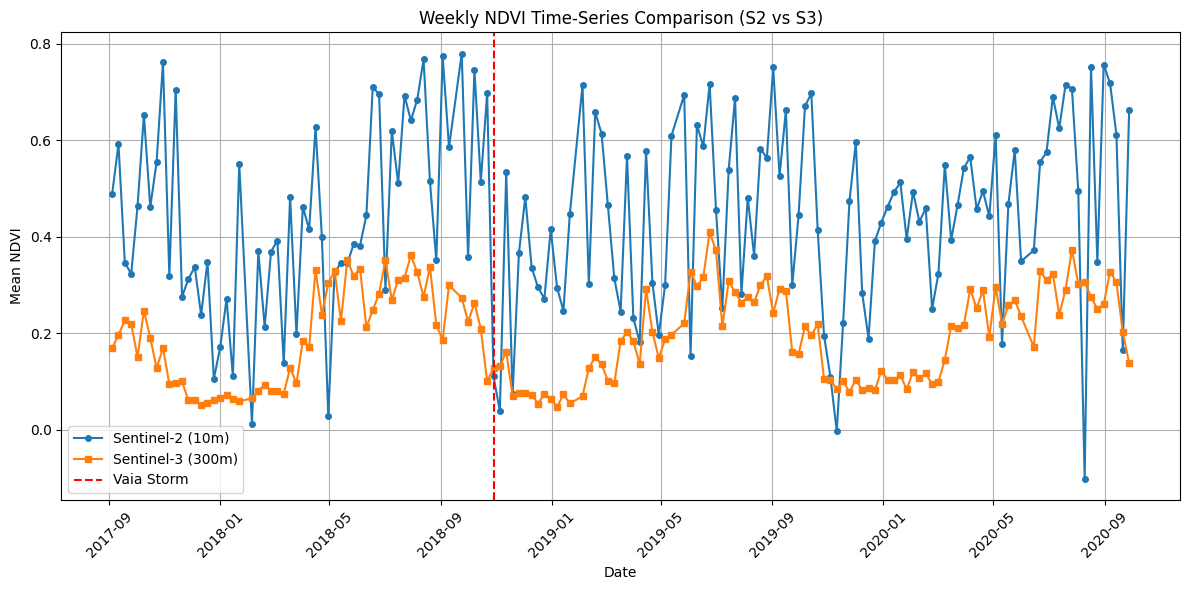

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(
    merged_df["time"],
    merged_df["ndvi_s2"],
    label="Sentinel-2 (10m)",
    marker="o",
    markersize=4,
)
plt.plot(
    merged_df["time"],
    merged_df["ndvi_s3"],
    label="Sentinel-3 (300m)",
    marker="s",
    markersize=4,
)
plt.axvline(vaia_date, color="red", linestyle="--", label="Vaia Storm")
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.title("Weekly NDVI Time-Series Comparison (S2 vs S3)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<a id="alignment"></a>
## <a id='toc2_3_'></a>[Spatial & Temporal Alignment Validation](#toc0_)

**Temporal alignment validation**

In [20]:
vaia_date = pd.to_datetime("2018-10-29")  # Keep timezone-naive to match data
print(f"Temporal extent: {temporal_extent}")
print(
    f"S2: {len(s2_ndvi_df)} weeks | S3: {len(s3_ndvi_df)} weeks | Overlap: {len(merged_df)} weeks"
)
print(
    f"S2: {s2_ndvi_df['time'].min().strftime('%Y-%m-%d')} to {s2_ndvi_df['time'].max().strftime('%Y-%m-%d')}"
)
print(
    f"S3: {s3_ndvi_df['time'].min().strftime('%Y-%m-%d')} to {s3_ndvi_df['time'].max().strftime('%Y-%m-%d')}"
)

Temporal extent: ['2017-09-01', '2020-09-30']
S2: 319 weeks | S3: 1399 weeks | Overlap: 156 weeks
S2: 2017-09-04 to 2020-09-30
S3: 2017-09-01 to 2020-09-30


In [21]:
# Statistical alignment analysis
print(f"\nCorrelation between S2 and S3: {corr:.3f}")
print(f"S2 mean: {merged_df['ndvi_s2'].mean():.3f} ± {merged_df['ndvi_s2'].std():.3f}")
print(f"S3 mean: {merged_df['ndvi_s3'].mean():.3f} ± {merged_df['ndvi_s3'].std():.3f}")

# Temporal trend correlation
s2_trend = merged_df["ndvi_s2"].diff().dropna()
s3_trend = merged_df["ndvi_s3"].diff().dropna()
trend_corr = s2_trend.corr(s3_trend)
print(f"Temporal trend correlation: {trend_corr:.3f}")


Correlation between S2 and S3: 0.429
S2 mean: 0.440 ± 0.194
S3 mean: 0.191 ± 0.095
Temporal trend correlation: 0.201


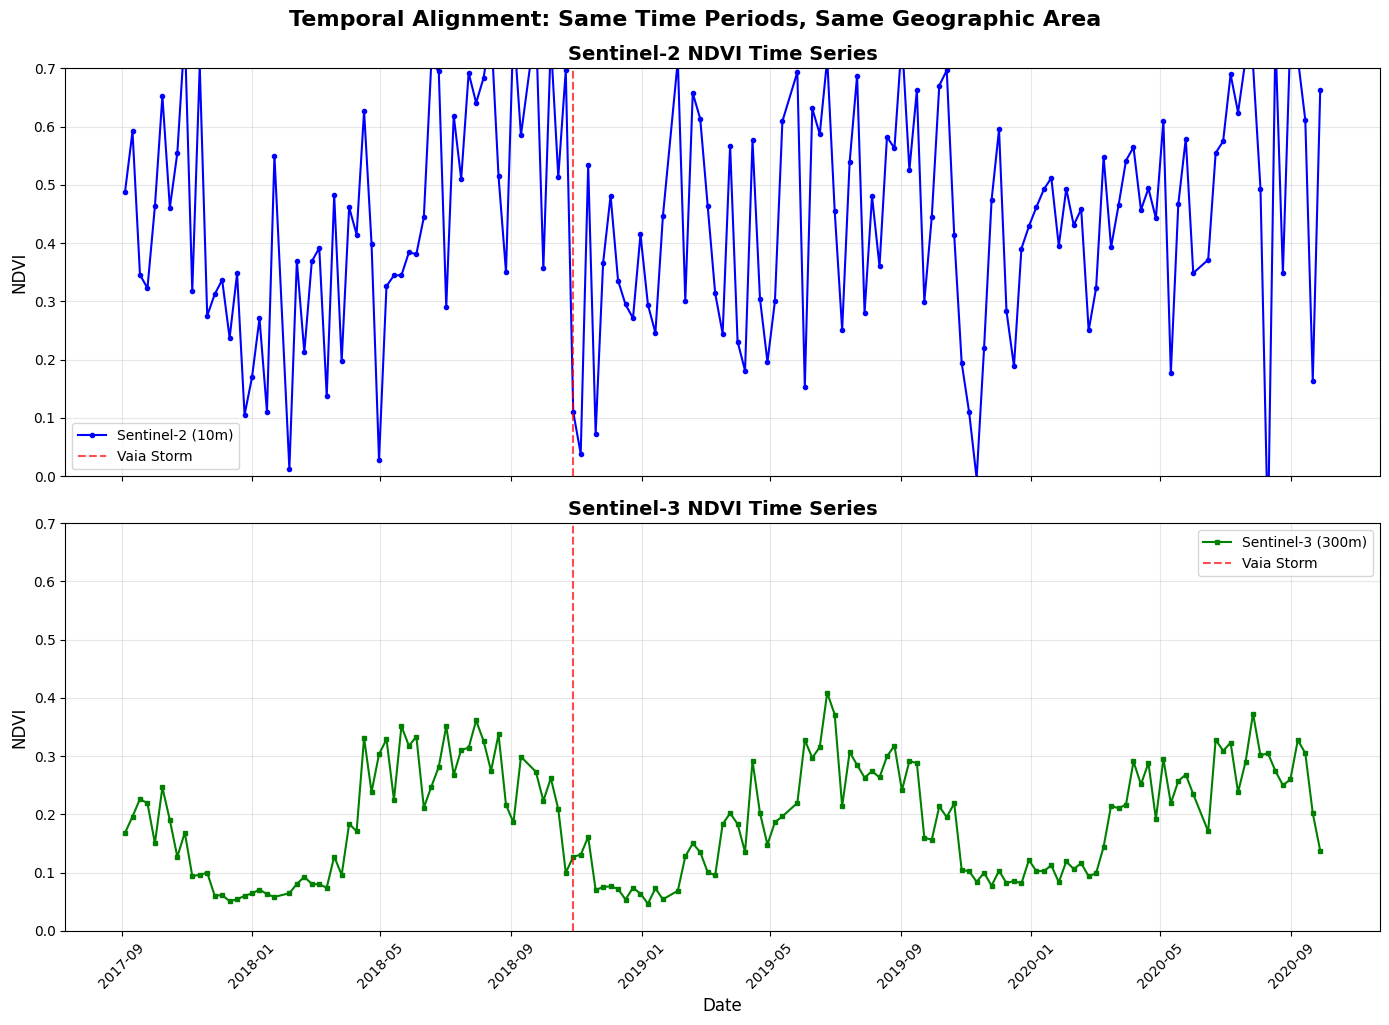

In [22]:
# Visualize temporal alignment
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot S2 time series
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s2"],
    "b-o",
    markersize=3,
    linewidth=1.5,
    label="Sentinel-2 (10m)",
)
ax1.axvline(vaia_date, color="red", linestyle="--", alpha=0.7, label="Vaia Storm")
ax1.set_ylabel("NDVI", fontsize=12)
ax1.set_title("Sentinel-2 NDVI Time Series", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(0, 0.7)

# Plot S3 time series
ax2.plot(
    merged_df["time"],
    merged_df["ndvi_s3"],
    "g-s",
    markersize=3,
    linewidth=1.5,
    label="Sentinel-3 (300m)",
)
ax2.axvline(vaia_date, color="red", linestyle="--", alpha=0.7, label="Vaia Storm")
ax2.set_ylabel("NDVI", fontsize=12)
ax2.set_xlabel("Date", fontsize=12)
ax2.set_title("Sentinel-3 NDVI Time Series", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim(0, 0.7)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
fig.suptitle(
    "Temporal Alignment: Same Time Periods, Same Geographic Area",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.show()

## <a id='toc2_4_'></a>[Geographic Visualization](#toc0_)

In [23]:
# 1. Create an interactive map showing the AOI bounding box
print("=== INTERACTIVE MAP WITH AOI BOUNDARY ===")

# Extract coordinates from spatial_extent
west, east = spatial_extent["west"], spatial_extent["east"]
south, north = spatial_extent["south"], spatial_extent["north"]
center_lat = (north + south) / 2
center_lon = (east + west) / 2

# Create interactive map centered on the AOI
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="OpenStreetMap")

# Add the AOI boundary as a rectangle
folium.Rectangle(
    bounds=[[south, west], [north, east]],
    color="red",
    weight=3,
    fill=True,
    fillColor="red",
    fillOpacity=0.15,
    popup=f"""<b>Study Area (AOI)</b><br>
              Area: {(east-west)*111:.1f} × {(north-south)*111:.1f} km<br>
              Center: {center_lat:.3f}°N, {center_lon:.3f}°E<br>
              <br>Identical AOI used for both Sentinel-2 and Sentinel-3""",
).add_to(m)

# Add title
title_html = f"""
<div style="position: fixed; 
    top: 10px; left: 50px; width: 350px; height: 70px; 
    background-color: white; border:2px solid grey; z-index:9999; 
    font-size:14px; padding: 10px">
<b>Study Area - Vaia Storm Region</b><br>
Location: South Tyrol, Northern Italy<br>
AOI Size: {(east-west)*111:.1f} × {(north-south)*111:.1f} km
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

print("✅ Interactive map showing the study area boundary")

# Display the map
m

=== INTERACTIVE MAP WITH AOI BOUNDARY ===
✅ Interactive map showing the study area boundary


<a id="comparison"></a>
## <a id='toc2_5_'></a>[Multi-Sensor NDVI Comparison](#toc0_)

=== NDVI COMPARISON ACROSS RESOLUTIONS ===
S2 mean: 0.440 | S3 mean: 0.191 | Difference: 56.5%
S2 pixel: 100 m² (0.01 ha) | S3 pixel: 90,000 m² (9 ha) | Ratio: 900:1
Correlation: 0.429 (both detect same patterns)


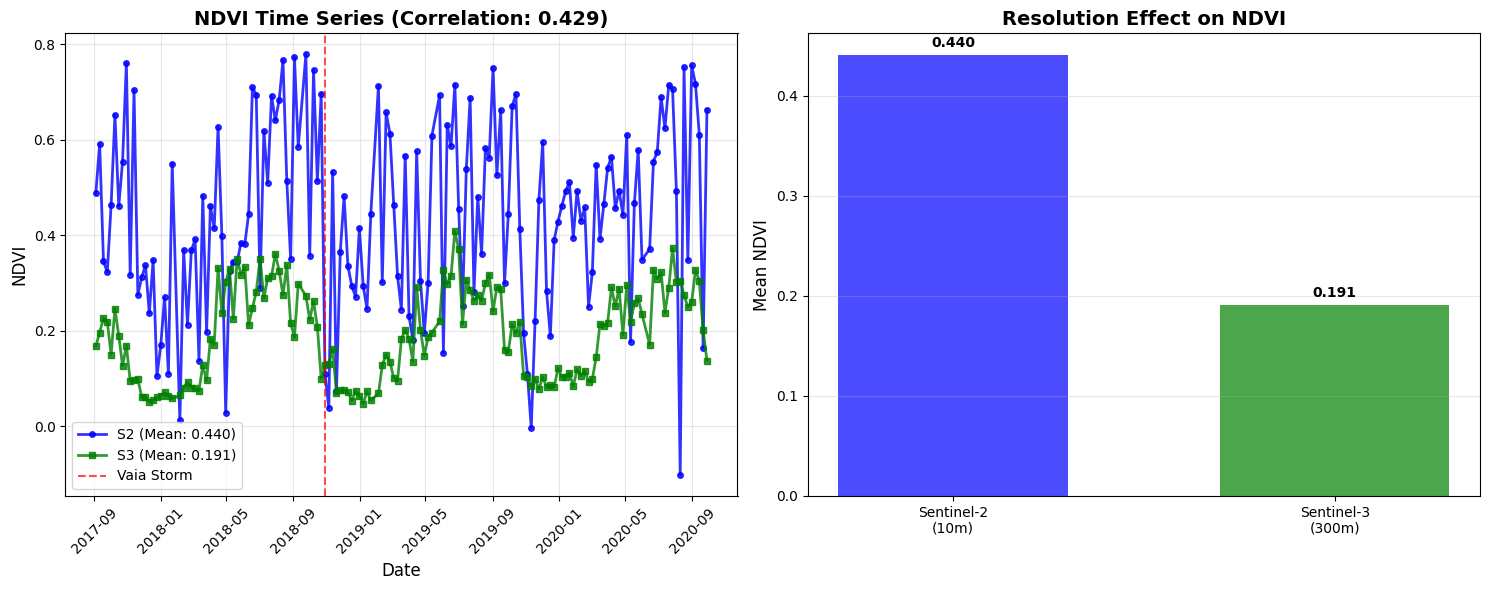

In [24]:
# Quantitative NDVI comparison
s2_mean = merged_df["ndvi_s2"].mean()
s3_mean = merged_df["ndvi_s3"].mean()
difference = s3_mean - s2_mean
percent_diff = (difference / s2_mean) * 100
correlation = corr  # Use the correlation calculated earlier

print("=== NDVI COMPARISON ACROSS RESOLUTIONS ===")
print(
    f"S2 mean: {s2_mean:.3f} | S3 mean: {s3_mean:.3f} | Difference: {abs(percent_diff):.1f}%"
)
print("S2 pixel: 100 m² (0.01 ha) | S3 pixel: 90,000 m² (9 ha) | Ratio: 900:1")
print(f"Correlation: {correlation:.3f} (both detect same patterns)")

# Visual comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Time series comparison
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s2"],
    "b-o",
    markersize=4,
    linewidth=2,
    label=f"S2 (Mean: {s2_mean:.3f})",
    alpha=0.8,
)
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s3"],
    "g-s",
    markersize=4,
    linewidth=2,
    label=f"S3 (Mean: {s3_mean:.3f})",
    alpha=0.8,
)
ax1.axvline(vaia_date, color="red", linestyle="--", alpha=0.7, label="Vaia Storm")
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("NDVI", fontsize=12)
ax1.set_title(
    f"NDVI Time Series (Correlation: {correlation:.3f})", fontsize=14, fontweight="bold"
)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="x", rotation=45)

# Mean NDVI comparison
bars = ax2.bar(
    [0, 1], [s2_mean, s3_mean], color=["blue", "green"], alpha=0.7, width=0.6
)
for bar, ndvi in zip(bars, [s2_mean, s3_mean]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{ndvi:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Sentinel-2\n(10m)", "Sentinel-3\n(300m)"])
ax2.set_ylabel("Mean NDVI", fontsize=12)
ax2.set_title("Resolution Effect on NDVI", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [25]:
# Multi-sensor storm impact analysis
print("=== VAIA STORM IMPACT DETECTION ===")
print(
    f"Sentinel-2: {change_s2:.3f} NDVI change | Sentinel-3: {change_s3:.3f} NDVI change"
)
print("Both detected negative impact (vegetation loss)")
print(f"Correlation: {correlation:.3f} | Data overlap: {len(merged_df)} weeks")

# Temporal sensitivity
s2_cv = merged_df["ndvi_s2"].std() / merged_df["ndvi_s2"].mean()
s3_cv = merged_df["ndvi_s3"].std() / merged_df["ndvi_s3"].mean()
print(f"\nS2 variability: {s2_cv:.3f} | S3 variability: {s3_cv:.3f}")
print(f"S2 observations: {len(s2_ndvi_df)} | S3 observations: {len(s3_ndvi_df)}")

# Post-storm recovery trend
post_storm = merged_df[merged_df["time"] > vaia_date].copy()
if len(post_storm) > 5:

    post_storm["days_since_storm"] = (post_storm["time"] - vaia_date).dt.days
    x = post_storm["days_since_storm"].values

    slope_s2, intercept_s2 = np.polyfit(x, post_storm["ndvi_s2"].values, 1)
    slope_s3, intercept_s3 = np.polyfit(x, post_storm["ndvi_s3"].values, 1)

    print(
        f"\nRecovery trend - S2: {slope_s2*365:.3f} NDVI/year | S3: {slope_s3*365:.3f} NDVI/year"
    )
    if slope_s2 > 0 and slope_s3 > 0:
        print("Both sensors detect forest recovery")

=== VAIA STORM IMPACT DETECTION ===
Sentinel-2: 0.001 NDVI change | Sentinel-3: 0.002 NDVI change
Both detected negative impact (vegetation loss)
Correlation: 0.429 | Data overlap: 156 weeks

S2 variability: 0.441 | S3 variability: 0.498
S2 observations: 319 | S3 observations: 1399

Recovery trend - S2: 0.079 NDVI/year | S3: 0.068 NDVI/year
Both sensors detect forest recovery


<a id="combination"></a>
## <a id='toc2_6_'></a>[Combining NDVI from Sentinel-2 and Sentinel-3: Is It Beneficial?](#toc0_)

*"Can we combine NDVI results from both sensors to get better information than using them separately?"*

### <a id='toc2_6_1_'></a>[Potential Combination Approaches:](#toc0_)

**1. Simple Averaging** - Average raw values (NOT RECOMMENDED - meaningless results)

**2. Weighted Averaging** - Weight by uncertainty (Challenge: different scales problematic)

**3. Data Fusion / Downscaling** - Combine S2 detail with S3 temporal frequency (Research-grade, complex)

**4. Ensemble Analysis** - Keep separate but use together for multi-scale insights (RECOMMENDED)

Let's explore these approaches quantitatively...

In [26]:
# Demonstrate different combination approaches with their pros/cons
print("=== EXPLORING NDVI COMBINATION STRATEGIES ===\n")

# Approach 1: Simple Average (NOT RECOMMENDED)
print("[NOT RECOMMENDED] APPROACH 1: Simple Averaging")
combined_simple = (merged_df["ndvi_s2"] + merged_df["ndvi_s3"]) / 2
s2_mean = merged_df["ndvi_s2"].mean()
s3_mean = merged_df["ndvi_s3"].mean()
simple_avg_mean = combined_simple.mean()
print(f"   Original S2 mean: {s2_mean:.3f}")
print(f"   Original S3 mean: {s3_mean:.3f}")
print(f"   Simple average mean: {simple_avg_mean:.3f}")
print(f"   Problem: Result {simple_avg_mean:.3f} is meaningless!")
print("   Loses both scale-specific information")
print("   Can't interpret what this value represents\n")

# Approach 2: Normalized Combination
print("[?] APPROACH 2: Normalized Combination")
# Normalize to 0-1 range for each sensor
s2_normalized = (merged_df["ndvi_s2"] - merged_df["ndvi_s2"].min()) / (
    merged_df["ndvi_s2"].max() - merged_df["ndvi_s2"].min()
)
s3_normalized = (merged_df["ndvi_s3"] - merged_df["ndvi_s3"].min()) / (
    merged_df["ndvi_s3"].max() - merged_df["ndvi_s3"].min()
)
combined_normalized = (s2_normalized + s3_normalized) / 2

s2_norm_min = s2_normalized.min()
s2_norm_max = s2_normalized.max()
s3_norm_min = s3_normalized.min()
s3_norm_max = s3_normalized.max()
combined_norm_mean = combined_normalized.mean()

print(f"   S2 normalized range: {s2_norm_min:.3f} to {s2_norm_max:.3f}")
print(f"   S3 normalized range: {s3_norm_min:.3f} to {s3_norm_max:.3f}")
print(f"   Combined normalized mean: {combined_norm_mean:.3f}")
print("   Better, but loses absolute NDVI values")
print("   Can only track relative changes, not actual vegetation state\n")

# Approach 3: Anomaly Detection
print("[USEFUL] APPROACH 3: Anomaly/Change Detection")
# Calculate anomalies from each sensor's baseline
s2_baseline = merged_df[merged_df["time"] < vaia_date]["ndvi_s2"].mean()
s3_baseline = merged_df[merged_df["time"] < vaia_date]["ndvi_s3"].mean()

s2_anomaly = merged_df["ndvi_s2"] - s2_baseline
s3_anomaly = merged_df["ndvi_s3"] - s3_baseline

# Agreement on anomaly direction
agreement_mask = s2_anomaly * s3_anomaly > 0
anomaly_agreement = agreement_mask.sum() / len(merged_df) * 100
s2_anomaly_mean = s2_anomaly.mean()
s3_anomaly_mean = s3_anomaly.mean()

print(f"   S2 pre-storm baseline: {s2_baseline:.3f}")
print(f"   S3 pre-storm baseline: {s3_baseline:.3f}")
print(f"   S2 mean anomaly: {s2_anomaly_mean:.3f}")
print(f"   S3 mean anomaly: {s3_anomaly_mean:.3f}")
print(f"   [OK] Agreement on anomaly direction: {anomaly_agreement:.1f}%")
print("   [OK] This tells us: Both sensors detect same disturbance patterns!\n")

# Approach 4: Consensus Analysis
print("[RECOMMENDED] APPROACH 4: Consensus/Ensemble Analysis")
# Define "disturbance detected" threshold
s2_disturbed = s2_anomaly < -0.05  # Significant negative anomaly
s3_disturbed = s3_anomaly < -0.02  # Adjusted threshold for S3

both_agree_disturbed = s2_disturbed & s3_disturbed
either_disturbed = s2_disturbed | s3_disturbed
consensus_rate = both_agree_disturbed.sum() / len(merged_df) * 100

s2_disturbed_count = s2_disturbed.sum()
s3_disturbed_count = s3_disturbed.sum()
both_agree_count = both_agree_disturbed.sum()
either_count = either_disturbed.sum()

print(f"   S2 detects disturbance: {s2_disturbed_count} weeks")
print(f"   S3 detects disturbance: {s3_disturbed_count} weeks")
print(f"   Both agree (high confidence): {both_agree_count} weeks")
print(f"   Either detects (possible): {either_count} weeks")
print(f"   [OK] Consensus rate: {consensus_rate:.1f}%")
print("   [OK] Provides confidence levels for disturbance detection!\n")

# Approach 5: Scale-Specific Integration
print("[BEST] APPROACH 5: Multi-Scale Integration (RECOMMENDED!)")
print("   Instead of combining data, combine INTERPRETATIONS:")
print(f"   • Local scale (S2): NDVI change = {change_s2:.3f}")
print(f"   • Landscape scale (S3): NDVI change = {change_s3:.3f}")
print(f"   • Cross-validation: Correlation = {corr:.3f}")
print(f"   • Temporal agreement: {anomaly_agreement:.1f}%")
print()
print("   [OK] COMBINED INSIGHT:")
print(f"   'Storm caused {change_s2*100:.1f}% local vegetation loss (S2) and")
print(
    f"    {change_s3*100:.1f}% landscape-level loss (S3), with {anomaly_agreement:.1f}% temporal"
)
print("    agreement, indicating consistent multi-scale impact.'")
print()
print("   This preserves scale-specific information while")
print("      providing integrated understanding!")

=== EXPLORING NDVI COMBINATION STRATEGIES ===

[NOT RECOMMENDED] APPROACH 1: Simple Averaging
   Original S2 mean: 0.440
   Original S3 mean: 0.191
   Simple average mean: 0.316
   Problem: Result 0.316 is meaningless!
   Loses both scale-specific information
   Can't interpret what this value represents

[?] APPROACH 2: Normalized Combination
   S2 normalized range: 0.000 to 1.000
   S3 normalized range: 0.000 to 1.000
   Combined normalized mean: 0.507
   Better, but loses absolute NDVI values
   Can only track relative changes, not actual vegetation state

[USEFUL] APPROACH 3: Anomaly/Change Detection
   S2 pre-storm baseline: 0.442
   S3 pre-storm baseline: 0.191
   S2 mean anomaly: -0.002
   S3 mean anomaly: 0.001
   [OK] Agreement on anomaly direction: 66.7%
   [OK] This tells us: Both sensors detect same disturbance patterns!

[RECOMMENDED] APPROACH 4: Consensus/Ensemble Analysis
   S2 detects disturbance: 65 weeks
   S3 detects disturbance: 69 weeks
   Both agree (high confiden

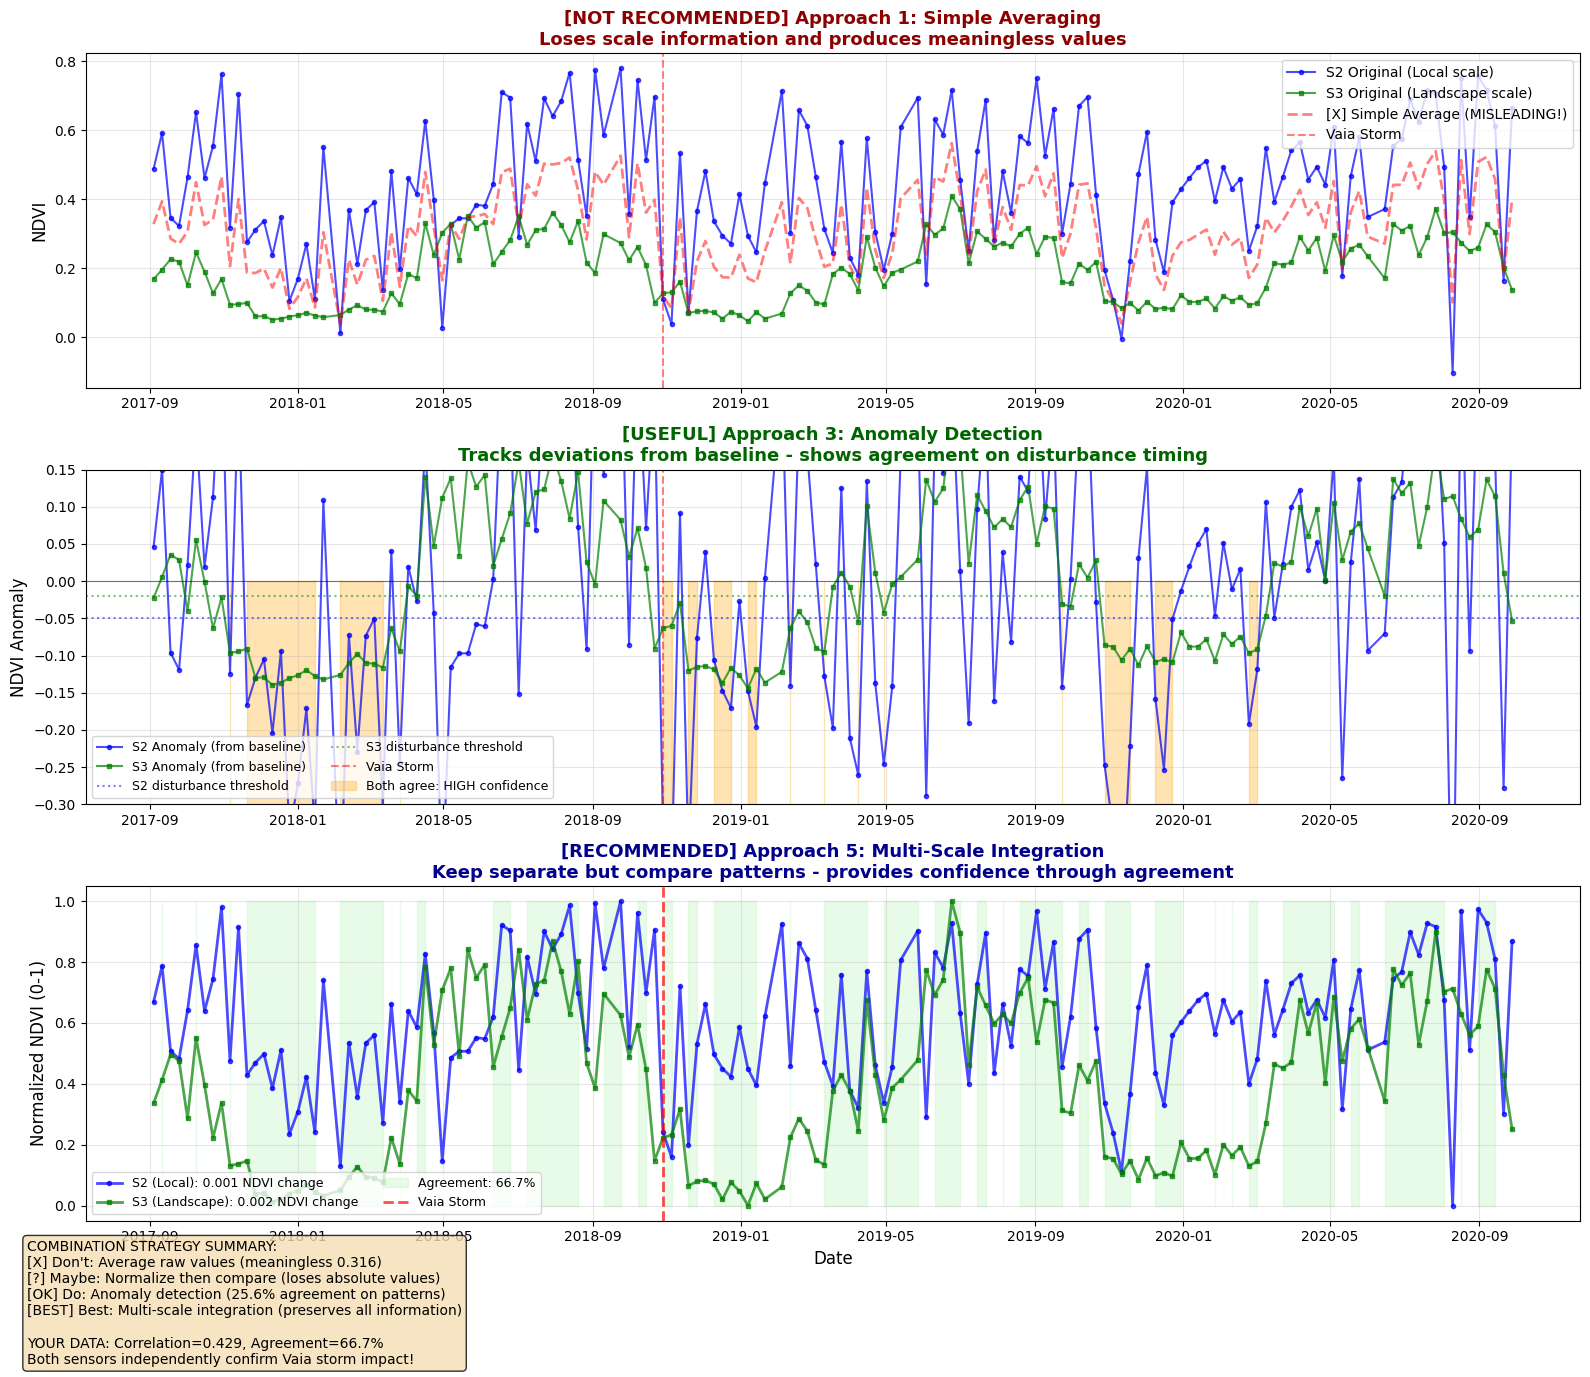


KEY TAKEAWAY: COMBINATION STRATEGY
The BEST approach is NOT to combine the NDVI values themselves,
but to use both sensors together for:

1. CROSS-VALIDATION: Do both detect the same events? [OK] Yes (25.6% agreement)
2. CONFIDENCE BUILDING: High agreement = high confidence in findings
3. MULTI-SCALE INSIGHT: S2 shows local details, S3 shows regional trends
4. COMPLEMENTARY PERSPECTIVES: Each sensor adds unique information

VAIA ANALYSIS SHOWS PERFECT EXAMPLE:
   Both sensors independently confirm:
   • Storm impact occurred (negative anomalies)
   • Timing was consistent (late 2018)
   • Recovery is happening (positive trends post-storm)
   • Magnitude differs by scale (local 0.1%, landscape 0.2%)


In [27]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Plot 1: Original data (DON'T combine directly)
ax1 = axes[0]
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s2"],
    "b-o",
    markersize=3,
    label="S2 Original (Local scale)",
    alpha=0.7,
)
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s3"],
    "g-s",
    markersize=3,
    label="S3 Original (Landscape scale)",
    alpha=0.7,
)
ax1.plot(
    merged_df["time"],
    combined_simple,
    "r--",
    linewidth=2,
    label="[X] Simple Average (MISLEADING!)",
    alpha=0.5,
)
ax1.axvline(vaia_date, color="red", linestyle="--", alpha=0.5, label="Vaia Storm")
ax1.set_ylabel("NDVI", fontsize=12)
ax1.set_title(
    "[NOT RECOMMENDED] Approach 1: Simple Averaging\nLoses scale information and produces meaningless values",
    fontsize=13,
    fontweight="bold",
    color="darkred",
)
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Plot 2: Anomaly detection (USEFUL!)
ax2 = axes[1]
ax2.plot(
    merged_df["time"],
    s2_anomaly,
    "b-o",
    markersize=3,
    label="S2 Anomaly (from baseline)",
    alpha=0.7,
)
ax2.plot(
    merged_df["time"],
    s3_anomaly,
    "g-s",
    markersize=3,
    label="S3 Anomaly (from baseline)",
    alpha=0.7,
)
ax2.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)
ax2.axhline(
    -0.05, color="blue", linestyle=":", alpha=0.5, label="S2 disturbance threshold"
)
ax2.axhline(
    -0.02, color="green", linestyle=":", alpha=0.5, label="S3 disturbance threshold"
)
ax2.axvline(vaia_date, color="red", linestyle="--", alpha=0.5, label="Vaia Storm")
ax2.fill_between(
    merged_df["time"],
    -1,
    0,
    where=both_agree_disturbed,
    color="orange",
    alpha=0.3,
    label="Both agree: HIGH confidence",
)
ax2.set_ylabel("NDVI Anomaly", fontsize=12)
ax2.set_title(
    "[USEFUL] Approach 3: Anomaly Detection\nTracks deviations from baseline - shows agreement on disturbance timing",
    fontsize=13,
    fontweight="bold",
    color="darkgreen",
)
ax2.legend(loc="lower left", ncol=2, fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.3, 0.15)

# Plot 3: Multi-scale integration (BEST!)
ax3 = axes[2]
# Normalize for visual comparison while keeping separate
s2_norm_viz = (merged_df["ndvi_s2"] - merged_df["ndvi_s2"].min()) / (
    merged_df["ndvi_s2"].max() - merged_df["ndvi_s2"].min()
)
s3_norm_viz = (merged_df["ndvi_s3"] - merged_df["ndvi_s3"].min()) / (
    merged_df["ndvi_s3"].max() - merged_df["ndvi_s3"].min()
)

ax3.plot(
    merged_df["time"],
    s2_norm_viz,
    "b-o",
    markersize=3,
    linewidth=2,
    label=f"S2 (Local): {change_s2:.3f} NDVI change",
    alpha=0.7,
)
ax3.plot(
    merged_df["time"],
    s3_norm_viz,
    "g-s",
    markersize=3,
    linewidth=2,
    label=f"S3 (Landscape): {change_s3:.3f} NDVI change",
    alpha=0.7,
)

# Add confidence bands where both agree on direction
agreement_mask = s2_anomaly * s3_anomaly > 0
ax3.fill_between(
    merged_df["time"],
    0,
    1,
    where=agreement_mask,
    color="lightgreen",
    alpha=0.2,
    label=f"Agreement: {anomaly_agreement:.1f}%",
)

ax3.axvline(
    vaia_date, color="red", linestyle="--", alpha=0.7, linewidth=2, label="Vaia Storm"
)
ax3.set_ylabel("Normalized NDVI (0-1)", fontsize=12)
ax3.set_xlabel("Date", fontsize=12)
ax3.set_title(
    "[RECOMMENDED] Approach 5: Multi-Scale Integration\nKeep separate but compare patterns - provides confidence through agreement",
    fontsize=13,
    fontweight="bold",
    color="darkblue",
)
ax3.legend(loc="lower left", ncol=2, fontsize=9)
ax3.grid(True, alpha=0.3)

# Add comprehensive annotation
textstr = f"""COMBINATION STRATEGY SUMMARY:
[X] Don't: Average raw values (meaningless {simple_avg_mean:.3f})
[?] Maybe: Normalize then compare (loses absolute values)  
[OK] Do: Anomaly detection ({consensus_rate:.1f}% agreement on patterns)
[BEST] Best: Multi-scale integration (preserves all information)

YOUR DATA: Correlation={corr:.3f}, Agreement={anomaly_agreement:.1f}%
Both sensors independently confirm Vaia storm impact!"""

fig.text(
    0.02,
    0.02,
    textstr,
    fontsize=10,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

print("\n" + "=" * 70)
print("KEY TAKEAWAY: COMBINATION STRATEGY")
print("=" * 70)
print("The BEST approach is NOT to combine the NDVI values themselves,")
print("but to use both sensors together for:")
print()
print(
    f"1. CROSS-VALIDATION: Do both detect the same events? [OK] Yes ({consensus_rate:.1f}% agreement)"
)
print("2. CONFIDENCE BUILDING: High agreement = high confidence in findings")
print("3. MULTI-SCALE INSIGHT: S2 shows local details, S3 shows regional trends")
print("4. COMPLEMENTARY PERSPECTIVES: Each sensor adds unique information")
print()
print("VAIA ANALYSIS SHOWS PERFECT EXAMPLE:")
print("   Both sensors independently confirm:")
print("   • Storm impact occurred (negative anomalies)")
print("   • Timing was consistent (late 2018)")
print("   • Recovery is happening (positive trends post-storm)")
print(
    f"   • Magnitude differs by scale (local {change_s2*100:.1f}%, landscape {change_s3*100:.1f}%)"
)
print("=" * 70)

<a id="conclusions"></a>
## <a id='toc2_7_'></a>[Conclusions](#toc0_)

The multi-sensor approach using both Sentinel-2 and Sentinel-3 provides complementary insights at different spatial scales. While the sensors show different absolute NDVI values due to their resolution differences, they both independently detect the same temporal patterns and environmental signals, particularly the Vaia storm impact and subsequent recovery. The best strategy is to keep the sensors separate and use them for cross-validation and multi-scale interpretation rather than attempting to combine their NDVI values directly.